HERE IS THE PIPELINE FOR ROIS PARCELATION USING 
1. LOAD FMRI DATA INTO FSL 
2. OPE FSLEYES DOWNLAODED IN VIRTUAL ENVIRONMENT 
3. LOAD OF ATLASES 
4. SELECT THE REGIONS OF INTEREST SPECIFICALLY FOR 2X2 
5. CREATE A MASK SO SAVE THOSE SELECTED REGIONS 
6. EXTRACT THE MASK FOR THE DATA 


SImulation using development data, using ROI from atals ut the dataset i use will have stages labelled. right now im just dividing by 4 whcih is bad 


PROCESSING ROIS AND SLEEP STAGES 
CLASSICAL PIPELINE 
1. PREPROCESSING, MOTION CORRECTION, SLICE TIMING CORRECTION, SPATIAL NORMALIZATION, FILTER UNCERTAIN AND UNSCORABLE 
2. ROI DEFINTION USING A STANDARD LIBRARY AAL, HARVARD-OXFORD IMPORT USING NILEARN 
3. EXTRACT TIME SERIES FROM ROI 
4. MATCH FMRI WITH SLEEP STAGES, SEGMENT SLEEP STAGES W, NMRE1, NREM2, NMRE3 
5. COMPUTE COVARIANCE MATRIX: WITH INCREASING SIZE FOR EACH SLEEP STAGE 
6. PERFORM CLASSICAL PCA ON COVARIANCE MATRICE ? SLIDING WINDOWS 


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from nilearn import datasets, plotting 
from nilearn.maskers import NiftiMapsMasker
import seaborn as sns 
from sklearn.decomposition import PCA 
import sys
print(sys.executable) 

#load a sample dataset 
development_dataset = datasets.fetch_adhd(n_subjects=1)

# Print the keys to see what's available in the dataset
print("Dataset keys:", development_dataset.keys())

# Print the description
print("Description:", development_dataset.description)

# Access specific elements (examples)
print("Subjects directories:", development_dataset.func)
print("Confounds:", development_dataset.confounds)




/opt/anaconda3/bin/python


[get_dataset_dir] Dataset created in /Users/alisonholmes/nilearn_data/adhd

[fetch_single_file] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...

[fetch_single_file]  ...done. (0 seconds, 0 min)

[uncompress_file] Extracting data from 
/Users/alisonholmes/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...

...

[_chunk_report_] Downloaded 44105728 of 44414948 bytes (99.3%%,    0.3s remaining)

[fetch_single_file]  ...done. (43 seconds, 0 min)

[uncompress_file] Extracting data from 
/Users/alisonholmes/nilearn_data/adhd/e7ff5670bd594dcd9453e57b55d69dc9/adhd40_0010042.tgz...

[uncompress_file] .. done.

Dataset keys: dict_keys(['func', 'confounds', 'phenotypic', 'description'])
Description: .. _adhd_dataset:

ADHD dataset

Access
------
See :func:`nilearn.datasets.fetch_adhd`.

Notes
-----
Part of the 1000 Functional Connectome Project. Phenotypic
information includes: diagnostic status, dimensional ADHD symptom measures,
age, sex, intelligence quotient (IQ) and lifetime medication status.
Preliminary quality control assessments (usable vs. questionable) based upon
visual timeseries inspection are included for all :term:`resting-state` :term:`fMRI` scans.

Includes preprocessed data from 40 participants.

Project was coordinated by Michael P. Milham.

See :footcite:t:`ADHDdataset`.

Content
-------
    :'func': Nifti images of the :term:`resting-state` data
    :'phenotypic': Explanations of preprocessing steps
    :'confounds': CSV files containing the nuisance variables

References
----------

.. footbibliography::

For more information about this dataset's structure:
http://fcon_10

In [3]:
#load the atlas 
atlas = datasets.fetch_atlas_msdl()

for i, label in enumerate(atlas.labels):
    print(f"Index {i}: {label}")
    

[get_dataset_dir] Dataset found in /Users/alisonholmes/nilearn_data/msdl_atlas

Index 0: L Aud
Index 1: R Aud
Index 2: Striate
Index 3: L DMN
Index 4: Med DMN
Index 5: Front DMN
Index 6: R DMN
Index 7: Occ post
Index 8: Motor
Index 9: R DLPFC
Index 10: R Front pol
Index 11: R Par
Index 12: R Post Temp
Index 13: Basal
Index 14: L Par
Index 15: L DLPFC
Index 16: L Front pol
Index 17: L IPS
Index 18: R IPS
Index 19: L LOC
Index 20: Vis
Index 21: R LOC
Index 22: D ACC
Index 23: V ACC
Index 24: R A Ins
Index 25: L STS
Index 26: R STS
Index 27: L TPJ
Index 28: Broca
Index 29: Sup Front S
Index 30: R TPJ
Index 31: R Pars Op
Index 32: Cereb
Index 33: Dors PCC
Index 34: L Ins
Index 35: Cing
Index 36: R Ins
Index 37: L Ant IPS
Index 38: R Ant IPS


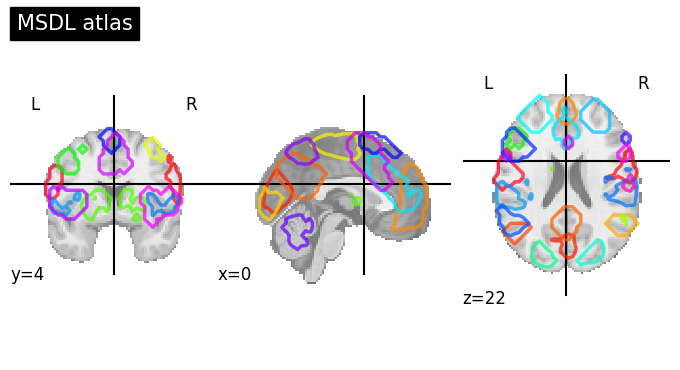

In [4]:

from nilearn.image import index_img

# Extract the first 3D map from the 4D atlas
first_map = index_img(atlas.maps, 0)

# Now plot this 3D map
#display = plotting.plot_roi(first_map, title="First region in MSDL atlas")
#plotting.show()

# If you want to plot all regions, you can use plot_prob_atlas instead
display = plotting.plot_prob_atlas(atlas.maps, title="MSDL atlas")
plotting.show()



In [5]:
# 2×2 matrix
roi_2x2 = [13, 5]

# 4×4 matrix
roi_4x4 = [13, 5, 33, 4]

# 8×8 matrix
roi_8x8 = [13, 5, 33, 4, 35, 22, 32, 2]

# 16×16 matrix
roi_16x16 = [13, 5, 33, 4, 35, 22, 32, 2, 24, 34, 8, 0, 1, 9, 15, 20]

# Step 4: Select specific ROIs for your analysis
# Here we select the first 4 ROIs as an example
selected_roi_2x2_indices = [13, 5]  # Modify this to include your regions of interest
selected_labels = [atlas.labels[i] for i in selected_roi_2x2_indices]
print(f"Selected ROIs: {selected_labels}")

Selected ROIs: ['Basal', 'Front DMN']


In [6]:
#Extract time series from these ROIs
print("Extracting time series from all ROIs...")
masker = NiftiMapsMasker(
    maps_img=atlas.maps,
    standardize="zscore_sample",
    memory="nilearn_cache",
    verbose=0
)



Extracting time series from all ROIs...


In [7]:
# Extract time series for the first subject
time_series = masker.fit_transform(development_dataset.func[0])

print(f"Time series shape: {time_series.shape}")
print(f"Number of time points: {time_series.shape[0]}")
print(f"Number of ROIs: {time_series.shape[1]}")

# Step 6: Calculate basic covariance matrices for selected ROIs
# 2x2 matrix for first two ROIs
selected_roi_2x2 = time_series[:, selected_roi_2x2_indices[:2]]
covariance_matrix_2x2 = np.cov(selected_roi_2x2.T)
print(f"\n2x2 Covariance matrix for first two ROIs:")
print(covariance_matrix_2x2)

/opt/anaconda3/lib/python3.12/site-packages/nilearn/maskers/base_masker.py:282: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  return self.transform_single_imgs(


Time series shape: (168, 39)
Number of time points: 168
Number of ROIs: 39

2x2 Covariance matrix for first two ROIs:
[[1.         0.48230695]
 [0.48230695 1.        ]]


In [8]:
#Simulate sleep stage labels (0=Wake, 1=NREM1, 2=NREM2, 3=NREM3) like the openNeuro dataset i want to use 
# Simulate sleep stage labels (0=Wake, 1=NREM1, 2=NREM2, 3=NREM3)
# Dividing the 168 time points equally among the 4 sleep stages
sleep_stages = np.concatenate([
    np.ones(42) * 0,  # Wake (0)
    np.ones(42) * 1,  # NREM1 (1)
    np.ones(42) * 2,  # NREM2 (2)
    np.ones(42) * 3,  # NREM3 (3)
])

print(f"Time series shape: {time_series.shape}")
print(f"Number of time points: {time_series.shape[0]}")
print(f"Sleep stages shape: {sleep_stages.shape}")


Time series shape: (168, 39)
Number of time points: 168
Sleep stages shape: (168,)


In [9]:
#extract time series for the 2 roi for the first covariance matrix 
selected_time_series = time_series[:, selected_roi_2x2_indices]


In [10]:
def compute_sleep_stage_covariance(time_series, sleep_stages, roi_indices=None):
    """
    Compute covariance matrices for each sleep stage
    
    Parameters:
    -----------
    time_series : Time series data for all ROIs
    sleep_stages :  Sleep stage label for each time point
    roi_indices : list of int, optional
        Indices of ROIs to include in analysis idk about this one 
        
    Returns:
    --------
    dict
        Covariance matrices for each sleep stage
    dict
        Number of time points per sleep stage
    """
    # If specific ROIs are provided, select only those
    if roi_indices is not None:
        time_series = time_series[:, roi_indices]
    
    # Calculate number of unique sleep stages
    unique_stages = np.unique(sleep_stages)
    covariance_matrices = {}
    timepoints_per_stage = {}
    
    for stage in unique_stages:
        # Extract data for this sleep stage
        stage_mask = (sleep_stages == stage)
        stage_data = time_series[stage_mask, :]
        
        # Store number of time points for this stage
        timepoints_per_stage[int(stage)] = stage_data.shape[0]
        
        # Compute covariance
        cov_matrix = np.cov(stage_data.T)
        covariance_matrices[int(stage)] = cov_matrix
        
        print(f"Stage {stage}: {stage_data.shape[0]} time points")
    
    return covariance_matrices, timepoints_per_stage

In [11]:
# Extract time series for selected ROIs
print("\nExtracting time series for selected ROIs...")
selected_time_series = time_series[:, selected_roi_2x2_indices]
print(f"Selected time series shape: {selected_time_series.shape}")

#Compute covariance matrices for each sleep stage
print("\nComputing covariance matrices for each sleep stage...")
cov_matrices, timepoints_per_stage = compute_sleep_stage_covariance(selected_time_series, sleep_stages)

stage_names = {0: "Wake", 1: "NREM1", 2: "NREM2", 3: "NREM3"}
print("\nCovariance matrices for each sleep stage:")
for stage, matrix in cov_matrices.items():
    print(f"\n{stage_names[stage]} (Stage {stage}) - {timepoints_per_stage[stage]} timepoints:")
    print(matrix)




Extracting time series for selected ROIs...
Selected time series shape: (168, 2)

Computing covariance matrices for each sleep stage...
Stage 0.0: 42 time points
Stage 1.0: 42 time points
Stage 2.0: 42 time points
Stage 3.0: 42 time points

Covariance matrices for each sleep stage:

Wake (Stage 0) - 42 timepoints:
[[ 0.65890825 -0.0083474 ]
 [-0.0083474   0.78565819]]

NREM1 (Stage 1) - 42 timepoints:
[[0.70291691 0.323597  ]
 [0.323597   0.90818283]]

NREM2 (Stage 2) - 42 timepoints:
[[0.86852498 0.52789128]
 [0.52789128 0.97649058]]

NREM3 (Stage 3) - 42 timepoints:
[[0.46178685 0.41822019]
 [0.41822019 1.00626551]]


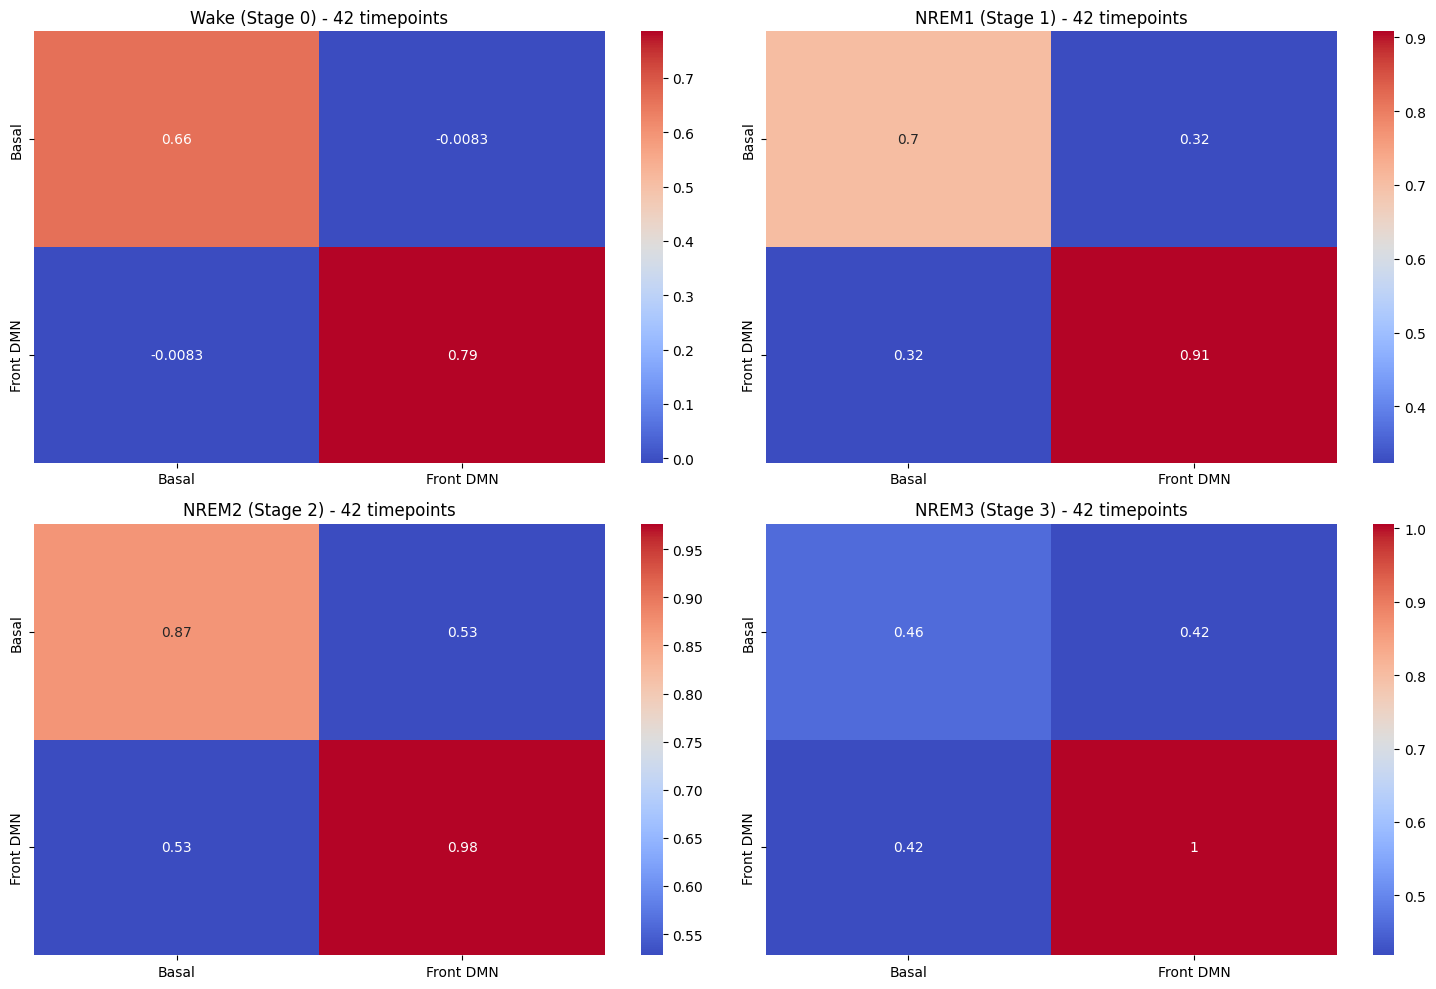

In [12]:
plt.figure(figsize=(15, 10))
for i, (stage, matrix) in enumerate(cov_matrices.items()):
    plt.subplot(2, 2, i+1)
    sns.heatmap(matrix, annot=True, cmap='coolwarm',
                xticklabels=selected_labels, yticklabels=selected_labels)
    plt.title(f"{stage_names[stage]} (Stage {stage}) - {timepoints_per_stage[stage]} timepoints")

plt.tight_layout()
plt.savefig('sleep_stage_covariance_matrices.png')
plt.show()


#if symmetry of matrics isnt achieved i will ahve to preprocess them to make sure they are hermititian. 



Sleep Stage: Wake
Explained Variance Ratio: [1.00000000e+00 1.33770759e-33]
Principal Components:
[[-5.1857376e-01  1.8966672e-17]
 [ 5.1857376e-01  1.8966672e-17]]

Sleep Stage: NREM1
Explained Variance Ratio: [1.00000000e+00 8.94842738e-35]
Principal Components:
[[-3.48433705e-01  3.29604792e-18]
 [ 3.48433705e-01  3.29604792e-18]]

Sleep Stage: NREM2
Explained Variance Ratio: [1.00000000e+00 1.09625535e-31]
Principal Components:
[[-2.81634803e-01 -9.32485709e-17]
 [ 2.81634803e-01 -9.32485709e-17]]

Sleep Stage: NREM3
Explained Variance Ratio: [1.00000000e+00 8.10803897e-33]
Principal Components:
[[-2.94828489e-01  2.65477281e-17]
 [ 2.94828489e-01  2.65477281e-17]]



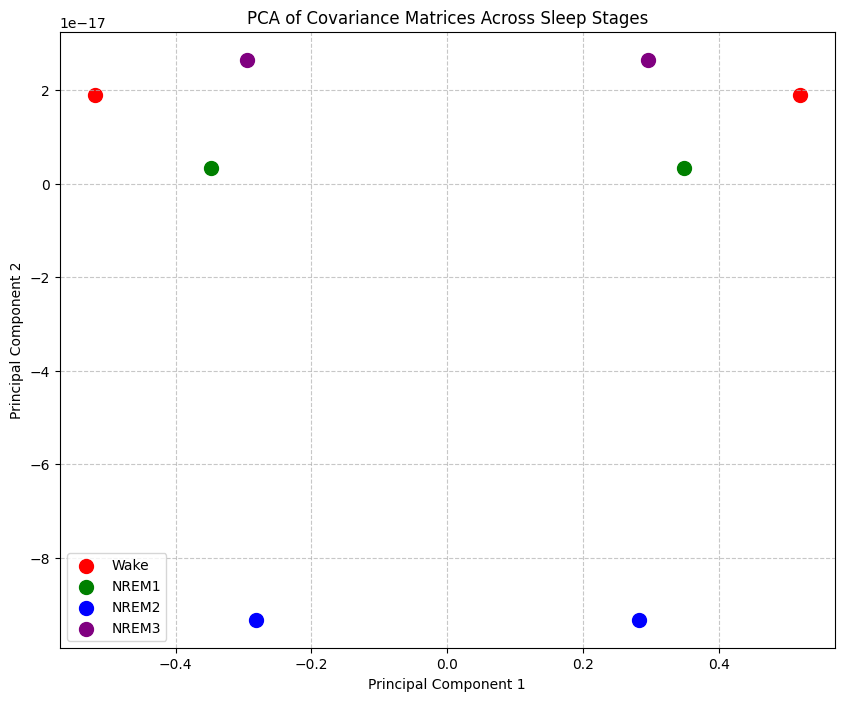

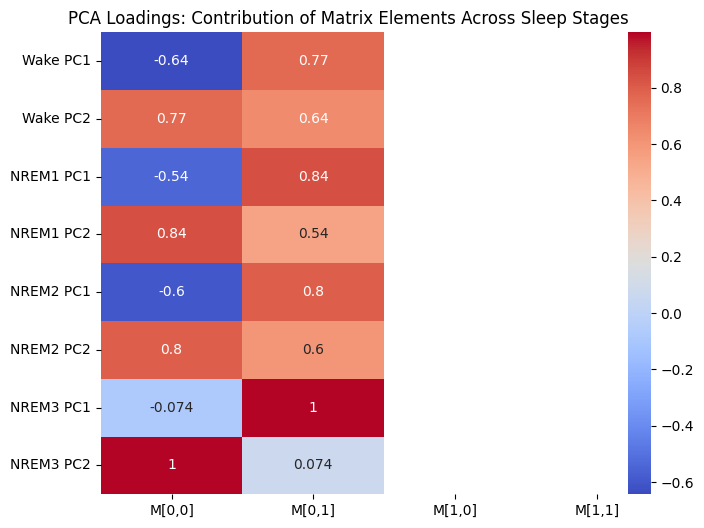

In [20]:
#PCA of these 4 covariance matrices 2x2 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Covariance matrices for each sleep stage
cov_matrices = {
    0: np.array([[0.65890825, -0.0083474], [-0.0083474, 0.78565819]]),  # Wake
    1: np.array([[0.70291691, 0.323597], [0.323597, 0.90818283]]),      # NREM1
    2: np.array([[0.86852498, 0.52789128], [0.52789128, 0.97649058]]),  # NREM2
    3: np.array([[0.46178685, 0.41822019], [0.41822019, 1.00626551]])   # NREM3
}

stage_names = {0: 'Wake', 1: 'NREM1', 2: 'NREM2', 3: 'NREM3'}

# Perform PCA separately for each 2x2 covariance matrix
principal_components = {}
explained_variances = {}

for stage, matrix in cov_matrices.items():
    pca = PCA(n_components=2)
    pc = pca.fit_transform(matrix)  # PCA on each individual covariance matrix
    principal_components[stage] = pc
    explained_variances[stage] = pca.explained_variance_ratio_

    print(f"Sleep Stage: {stage_names[stage]}")
    print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"Principal Components:\n{pc}\n")

# Visualization of PCA results
plt.figure(figsize=(10, 8))
colors = ['r', 'g', 'b', 'purple']

for i, (stage, pc) in enumerate(principal_components.items()):
    plt.scatter(pc[:, 0], pc[:, 1], s=100, label=stage_names[stage], color=colors[i])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Covariance Matrices Across Sleep Stages")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# PCA Loadings Analysis
plt.figure(figsize=(8, 6))
loadings = []
matrix_elements = ["M[0,0]", "M[0,1]", "M[1,0]", "M[1,1]"]

for stage, matrix in cov_matrices.items():
    pca = PCA(n_components=2)
    pca.fit(matrix)
    loadings.append(pca.components_)

sns.heatmap(np.vstack(loadings), annot=True, cmap='coolwarm', xticklabels=matrix_elements, 
            yticklabels=[f"{stage_names[stage]} PC{i+1}" for stage in stage_names for i in range(2)])

plt.title("PCA Loadings: Contribution of Matrix Elements Across Sleep Stages")
plt.show()